# Performance das Datas Duplas — Home Electronics (1P vs 3P)

Este notebook compara a performance da última data dupla (**9/9**, ontem) com as
datas duplas anteriores do ano (**8/8, 7/7, 6/6, 5/5, 4/4, 3/3, 2/2, 1/1**), com quebra:

- por **categoria agg1** dentro da vertical *Home Electronics*
- por **canal**: 1P (venda própria) vs 3P (marketplace/sellers)

Métricas: **GMV**, **Unidades vendidas** e **Market Share**.

O market share usa as tabelas oficiais de mercado (NeoTrust/Yipit) do dataset `WHOWNER`,
em vez de ser estimado. Como essas tabelas são semanais/mensais (não diárias) e não têm
a granularidade interna de canal/categoria, o share é lido no nível de **vertical Home
Electronics como um todo**, na semana (e no mês, como contexto) que contém cada data dupla.

> **Como usar este notebook**
> 1. Preencha as constantes na célula *Configuração* com o projeto/tabela de vendas reais do BigQuery.
> 2. Rode a seção **2b. Descoberta de schema** primeiro e confirme os nomes reais de coluna
>    nas tabelas de market share — os nomes usados nas queries (`player`, `gmv_share`, `week_iso` etc.)
>    são hipóteses baseadas em convenções comuns e precisam ser validados.
> 3. Ajuste as queries em `build_sales_query` / `build_weekly_share_query` / `build_monthly_share_query` para o esquema real.
> 4. Mude `USE_SAMPLE_DATA = False` para rodar contra o BigQuery.
>
> Por padrão (`USE_SAMPLE_DATA = True`) o notebook roda de ponta a ponta com **dados sintéticos**,
> só para validar toda a estrutura de análise e os gráficos antes de plugar os dados reais.

**Dependências:** `pip install pandas numpy matplotlib google-cloud-bigquery db-dtypes`


In [1]:
import numpy as np
import pandas as pd
from datetime import date

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


## 1. Configuração

In [2]:
# ── CONFIGURAÇÃO ──────────────────────────────────────────────────────
# TODO: preencha com os identificadores reais do seu ambiente BigQuery.
PROJECT_ID   = "SEU_PROJECT_ID"              # ex.: "meli-bi-data-prod"
SALES_TABLE  = "SEU_DATASET.fact_sales"      # tabela de vendas, grão pedido/item

# Vertical de interesse dentro da hierarquia agg1
AGG1_VERTICAL = "Home Electronics"

# Datas duplas a comparar — a mais recente (9/9) primeiro.
# Ajuste o ano/lista conforme o calendário promocional real.
DOUBLE_DATES = [
    ("9/9", date(2026, 9, 9)),
    ("8/8", date(2026, 8, 8)),
    ("7/7", date(2026, 7, 7)),
    ("6/6", date(2026, 6, 6)),
    ("5/5", date(2026, 5, 5)),
    ("4/4", date(2026, 4, 4)),
    ("3/3", date(2026, 3, 3)),
    ("2/2", date(2026, 2, 2)),
    ("1/1", date(2026, 1, 1)),
]

# Ordem cronológica (mais antiga → mais recente), usada nos eixos dos gráficos
CHRONO_ORDER = [label for label, _ in DOUBLE_DATES][::-1]

# True  = usa dados sintéticos (não requer acesso ao BigQuery) — útil para validar o notebook
# False = executa as queries reais definidas na seção 2
USE_SAMPLE_DATA = True

# ── MARKET SHARE (tabelas oficiais NeoTrust/Yipit, dataset WHOWNER) ─────
# Granularidade: semanal (WEEKLY_PLAYERS) ou mensal (as demais) — não existe
# leitura de share por dia exato, por isso usamos a semana/mês que contém a data dupla.
TBL_MKTSHARE_WEEKLY_PLAYERS         = "WHOWNER.DM_MARKETSHARE_WEEKLY_PLAYERS"          # share semanal por player — fonte principal
TBL_MKTSHARE_MONTHLY_NEOTRUST_YIPIT = "WHOWNER.DM_MARKETSHARE_MONTHLY_NEOTRUST_YIPIT_D1_MLB"  # share mensal MLB — contexto/validação
TBL_MARKET_ASP_MONTHLY_VERTICAL     = "WHOWNER.DM_MARKET_ASP_MONTHLY_VERTICAL_D1"       # ticket médio (ASP) de mercado — contexto
TBL_MARKET_MONTHLY_PLAYERS          = "WHOWNER.DM_MARKET_MONTHLY_PLAYERS"               # extensão opcional (ranking de players)
TBL_MKTSHARE_VERTICAL_UF_MONTHLY    = "WHOWNER.DM_MARKETSHARE_VERTICAL_D1_UF_MONTHLY"   # extensão opcional (quebra por UF)
TBL_MKTSHARE_SEGMENTATION_NEOTRUST  = "WHOWNER.DM_MARKETSHARE_SEGMENTATION_NEOTRUST_D1" # extensão opcional (quebra por segmento)

MELI_PLAYER_NAME = "Mercado Livre"  # TODO: confirmar valor exato na coluna `player`/`seller` dessas tabelas


## 2. Extração dos dados (BigQuery)

Ajuste os nomes de colunas/tabelas conforme o schema real. O grão esperado da query de
vendas após o `GROUP BY` é **data dupla × categoria agg1 × canal**. As queries de market
share retornam o share por **player**, na semana/mês da data dupla, sem quebra por canal
ou categoria interna (isso não existe nas tabelas de painel de mercado).


In [3]:
def run_bigquery(sql):
    from google.cloud import bigquery
    client = bigquery.Client(project=PROJECT_ID)
    return client.query(sql).to_dataframe()


def yoy_date(d):
    """Mesma data dupla, um ano antes — para o comparativo YoY."""
    return d.replace(year=d.year - 1)


def mom_date(d):
    """Mesmo dia, um mês antes — para o comparativo MoM.
    Cai no último dia do mês anterior se o dia não existir (ex.: 31/mar -> 28/fev)."""
    import calendar
    month = d.month - 1 or 12
    year = d.year if d.month > 1 else d.year - 1
    day = min(d.day, calendar.monthrange(year, month)[1])
    return d.replace(year=year, month=month, day=day)


def build_sales_query(target_date):
    """GMV/NMV e unidades por categoria agg1 e canal, para uma data específica
    (usada tanto para as datas duplas quanto para as datas de referência de YoY/MoM)."""
    return f"""
    SELECT
      DATE(order_created_at)   AS order_date,
      agg1_category            AS agg1_category,   -- categoria dentro da vertical
      channel                  AS channel,          -- '1P' ou '3P'
      SUM(gmv_local)            AS gmv,
      SUM(units)                AS units
    FROM `{PROJECT_ID}.{SALES_TABLE}`
    WHERE DATE(order_created_at) = DATE('{target_date.isoformat()}')
      AND agg1_vertical = '{AGG1_VERTICAL}'
    GROUP BY 1, 2, 3
    """


def build_weekly_share_query(year_iso, week_iso):
    """Market share semanal por player — fonte principal, granularidade mais próxima da data dupla."""
    return f"""
    SELECT
      year_iso     AS year_iso,   -- TODO: confirmar nome da coluna de ano ISO
      week_iso     AS week_iso,   -- TODO: confirmar nome da coluna de semana ISO
      vertical     AS vertical,    -- TODO: confirmar nome da coluna de vertical/categoria
      player       AS player,      -- TODO: confirmar nome da coluna de player/seller
      gmv_share    AS gmv_share     -- TODO: confirmar nome da coluna de market share (GMV)
    FROM `{PROJECT_ID}.{TBL_MKTSHARE_WEEKLY_PLAYERS}`
    WHERE year_iso = {year_iso}
      AND week_iso = {week_iso}
      AND vertical = '{AGG1_VERTICAL}'
    """


def build_monthly_share_query(target_date):
    """Market share mensal (NeoTrust/Yipit, MLB) — contexto/validação, menos sensível ao efeito pontual do dia."""
    month = target_date.strftime("%Y-%m")
    return f"""
    SELECT
      month        AS month,       -- TODO: confirmar nome da coluna de mês
      vertical     AS vertical,
      player       AS player,
      gmv_share    AS gmv_share
    FROM `{PROJECT_ID}.{TBL_MKTSHARE_MONTHLY_NEOTRUST_YIPIT}`
    WHERE month = '{month}'
      AND vertical = '{AGG1_VERTICAL}'
    """


def build_asp_query(target_date):
    """Ticket médio (ASP) de mercado por vertical — contexto para interpretar GMV vs unidades."""
    month = target_date.strftime("%Y-%m")
    return f"""
    SELECT
      month        AS month,       -- TODO: confirmar nome da coluna de mês
      vertical     AS vertical,
      asp          AS asp           -- TODO: confirmar nome da coluna de ASP
    FROM `{PROJECT_ID}.{TBL_MARKET_ASP_MONTHLY_VERTICAL}`
    WHERE month = '{month}'
      AND vertical = '{AGG1_VERTICAL}'
    """


## 2b. Descoberta de schema (rode antes de ajustar as queries acima)

Os nomes de coluna usados em `build_weekly_share_query`, `build_monthly_share_query` e
`build_asp_query` (`player`, `gmv_share`, `week_iso`, `asp` etc.) são **hipóteses**
baseadas em convenções comuns de tabelas de painel de mercado. Rode a célula abaixo
contra as tabelas reais e ajuste as queries conforme o retorno.


In [4]:
def show_table_columns(table_fqn):
    """Lista as colunas reais de uma tabela `dataset.table` via INFORMATION_SCHEMA."""
    dataset, table = table_fqn.split(".", 1)
    sql = f"""
    SELECT column_name, data_type
    FROM `{PROJECT_ID}.{dataset}.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = '{table}'
    ORDER BY ordinal_position
    """
    return run_bigquery(sql)


# Descomente para inspecionar cada tabela de market share antes de rodar as queries:
# for tbl in [TBL_MKTSHARE_WEEKLY_PLAYERS, TBL_MKTSHARE_MONTHLY_NEOTRUST_YIPIT,
#             TBL_MARKET_ASP_MONTHLY_VERTICAL, TBL_MARKET_MONTHLY_PLAYERS,
#             TBL_MKTSHARE_VERTICAL_UF_MONTHLY, TBL_MKTSHARE_SEGMENTATION_NEOTRUST]:
#     print(f"--- {tbl} ---")
#     display(show_table_columns(tbl))


## 3. Dados sintéticos (modo demo, sem BigQuery)

O market share sintético simula o grão real das tabelas de painel: um valor por
**data dupla** (vertical Home Electronics como um todo), sem quebra por canal ou
categoria interna.


In [5]:
def generate_sample_data(seed=42):
    """Dados sintéticos com o mesmo schema esperado da extração real,
    só para validar a estrutura do notebook antes de plugar o BigQuery."""
    rng = np.random.default_rng(seed)
    categories = ["TVs", "Áudio e Som", "Linha Branca", "Pequenos Eletrodomésticos", "Climatização"]
    channels = ["1P", "3P"]
    cat_weight = {"TVs": 1.4, "Áudio e Som": 0.8, "Linha Branca": 1.1,
                  "Pequenos Eletrodomésticos": 0.9, "Climatização": 0.7}

    # crescimento orgânico leve ao longo do ano + pico sazonal na própria 8/8 e 9/9
    growth_by_label = {label: 1 + 0.05 * i for i, label in enumerate(CHRONO_ORDER)}
    seasonal_boost = {"9/9": 1.40, "8/8": 1.35, "6/6": 1.12}

    rows = []
    for label, d in DOUBLE_DATES:
        boost = seasonal_boost.get(label, 1.0)
        for cat in categories:
            for ch in channels:
                ch_weight = 1.2 if ch == "1P" else 1.0
                noise = rng.normal(1.0, 0.05)
                gmv = 500_000 * cat_weight[cat] * ch_weight * growth_by_label[label] * boost * noise
                units = gmv / rng.normal(650, 40)
                rows.append(dict(date_label=label, order_date=d, agg1_category=cat,
                                  channel=ch, gmv=gmv, units=units))
    sales = pd.DataFrame(rows)

    # market share semanal simulado — grão: vertical Home Electronics x player,
    # sem quebra por canal/categoria interna (assim como nas tabelas reais do NeoTrust/Yipit)
    share_rows = []
    for label, _ in DOUBLE_DATES:
        base_share = 0.30 + 0.01 * growth_by_label[label]   # leve tendência de ganho de share no ano
        boost = 0.03 if seasonal_boost.get(label, 1.0) > 1.0 else 0.0  # pico de share na própria data dupla
        share_rows.append(dict(date_label=label, gmv_share=base_share + boost + rng.normal(0, 0.005)))
    market_share = pd.DataFrame(share_rows)

    # ticket médio (ASP) de mercado simulado — contexto adicional
    asp_rows = [dict(date_label=label, market_asp=rng.normal(720, 25)) for label, _ in DOUBLE_DATES]
    market_asp = pd.DataFrame(asp_rows)

    # NMV de referência para YoY (mesma data dupla do ano anterior, ~40% menor) e
    # MoM (mesmo dia um mês antes, ~15-25% menor) — só para o resumo formatado ter algo
    # plausível para exibir em modo demo.
    reference_rows = []
    for label, _ in DOUBLE_DATES:
        total_gmv = sales.loc[sales["date_label"] == label, "gmv"].sum()
        yoy_gmv = total_gmv / (1 + rng.uniform(0.45, 0.75))
        mom_gmv = total_gmv / (1 + rng.uniform(0.15, 0.40))
        reference_rows.append(dict(date_label=label, kind="yoy", gmv=yoy_gmv))
        reference_rows.append(dict(date_label=label, kind="mom", gmv=mom_gmv))
    reference = pd.DataFrame(reference_rows)

    return sales, market_share, market_asp, reference


## 4. Carregamento dos dados


In [6]:
def load_data():
    if USE_SAMPLE_DATA:
        return generate_sample_data()

    sales_frames = []
    for label, d in DOUBLE_DATES:
        sales_df = run_bigquery(build_sales_query(d))
        sales_df["date_label"] = label
        sales_frames.append(sales_df)
    sales = pd.concat(sales_frames, ignore_index=True)

    share_frames = []
    asp_frames = []
    reference_rows = []
    for label, d in DOUBLE_DATES:
        year_iso, week_iso, _ = d.isocalendar()
        share_df = run_bigquery(build_weekly_share_query(year_iso, week_iso))
        share_df = share_df.loc[share_df["player"] == MELI_PLAYER_NAME, ["gmv_share"]].copy()
        share_df["date_label"] = label
        share_frames.append(share_df)

        asp_df = run_bigquery(build_asp_query(d))[["asp"]].rename(columns={"asp": "market_asp"})
        asp_df["date_label"] = label
        asp_frames.append(asp_df)

        # YoY (mesma data dupla, ano anterior) e MoM (mesmo dia, mês anterior)
        yoy_df = run_bigquery(build_sales_query(yoy_date(d)))
        reference_rows.append(dict(date_label=label, kind="yoy", gmv=yoy_df["gmv"].sum()))
        mom_df = run_bigquery(build_sales_query(mom_date(d)))
        reference_rows.append(dict(date_label=label, kind="mom", gmv=mom_df["gmv"].sum()))

    market_share = pd.concat(share_frames, ignore_index=True)
    market_asp = pd.concat(asp_frames, ignore_index=True)
    reference = pd.DataFrame(reference_rows)

    return sales, market_share, market_asp, reference


df, df_market_share, df_market_asp, df_reference = load_data()
df["date_label"] = pd.Categorical(df["date_label"], categories=CHRONO_ORDER, ordered=True)
df_market_share["date_label"] = pd.Categorical(df_market_share["date_label"], categories=CHRONO_ORDER, ordered=True)
df_market_asp["date_label"] = pd.Categorical(df_market_asp["date_label"], categories=CHRONO_ORDER, ordered=True)
df_reference["date_label"] = pd.Categorical(df_reference["date_label"], categories=CHRONO_ORDER, ordered=True)
df.head()


,date_label,order_date,agg1_category,channel,gmv,units
0,9/9,2026-09-09,TVs,1P,"1,671,484.31","2,747.34"
1,9/9,2026-09-09,TVs,3P,"1,423,480.95","2,070.15"
2,9/9,2026-09-09,Áudio e Som,1P,"849,023.30","1,419.98"
3,9/9,2026-09-09,Áudio e Som,3P,"789,011.34","1,237.96"
4,9/9,2026-09-09,Linha Branca,1P,"1,292,513.30","2,098.65"


## 5. Agregações

In [7]:
overall = (df.groupby("date_label", observed=True)
             .agg(gmv=("gmv", "sum"), units=("units", "sum"))
             .reindex(CHRONO_ORDER))
overall = overall.join(df_market_share.set_index("date_label")["gmv_share"].rename("market_share"))
overall = overall.join(df_market_asp.set_index("date_label")["market_asp"])
overall["gmv_growth"] = overall["gmv"].pct_change()
overall["units_growth"] = overall["units"].pct_change()
overall["ticket_medio"] = overall["gmv"] / overall["units"]

reference_pivot = df_reference.pivot(index="date_label", columns="kind", values="gmv").reindex(CHRONO_ORDER)
overall["yoy_growth"] = overall["gmv"] / reference_pivot["yoy"] - 1
overall["mom_growth"] = overall["gmv"] / reference_pivot["mom"] - 1

by_channel = (df.groupby(["date_label", "channel"], observed=True)
                .agg(gmv=("gmv", "sum"), units=("units", "sum"))
                .reset_index())
by_channel_gmv = by_channel.pivot(index="date_label", columns="channel", values="gmv").reindex(CHRONO_ORDER)

by_category = (df.groupby(["date_label", "agg1_category"], observed=True)
                 .agg(gmv=("gmv", "sum"), units=("units", "sum"))
                 .reset_index())
cat_gmv_pivot = by_category.pivot(index="date_label", columns="agg1_category", values="gmv").reindex(CHRONO_ORDER)

by_channel_category = (df.groupby(["date_label", "agg1_category", "channel"], observed=True)
                          .agg(gmv=("gmv", "sum"), units=("units", "sum"))
                          .reset_index())

overall


,gmv,units,market_share,market_asp,gmv_growth,units_growth,ticket_medio,yoy_growth,mom_growth
date_label,,,,,,,,,
1/1,"5,429,587.62","8,528.50",0.30,710.13,NaN,NaN,636.64,0.73,0.25
2/2,"5,543,388.36","8,633.90",0.30,736.08,0.02,0.01,642.05,0.49,0.18
3/3,"5,937,549.93","9,142.18",0.31,697.63,0.07,0.06,649.47,0.66,0.33
4/4,"6,185,178.04","9,636.47",0.32,692.32,0.04,0.05,641.85,0.51,0.35
5/5,"6,386,852.98","10,037.45",0.31,756.54,0.03,0.04,636.30,0.66,0.30
6/6,"7,432,176.48","11,425.63",0.35,710.42,0.16,0.14,650.48,0.49,0.28
7/7,"6,990,946.53","10,556.95",0.31,715.51,-0.06,-0.08,662.21,0.49,0.32
8/8,"9,989,330.62","15,510.02",0.34,763.09,0.43,0.47,644.06,0.45,0.21
9/9,"10,669,932.90","16,696.08",0.35,761.27,0.07,0.08,639.07,0.60,0.19


## 6. Estilo dos gráficos

Paleta e tokens seguem o design system de referência: cor categórica em ordem fixa
(1P = azul, 3P = laranja), tinta secundária para rótulos/valores, grid discreto.

In [8]:
import matplotlib.pyplot as plt

COLOR_1P = "#2a78d6"
COLOR_3P = "#eb6834"
CAT_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]

TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
TEXT_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": TEXT_SECONDARY,
    "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "grid.color": GRIDLINE,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})


def brl_millions(x):
    return f"R$ {x/1e6:,.1f}M"


## 7. GMV total — 9/9 vs datas duplas anteriores (com quebra 1P/3P)


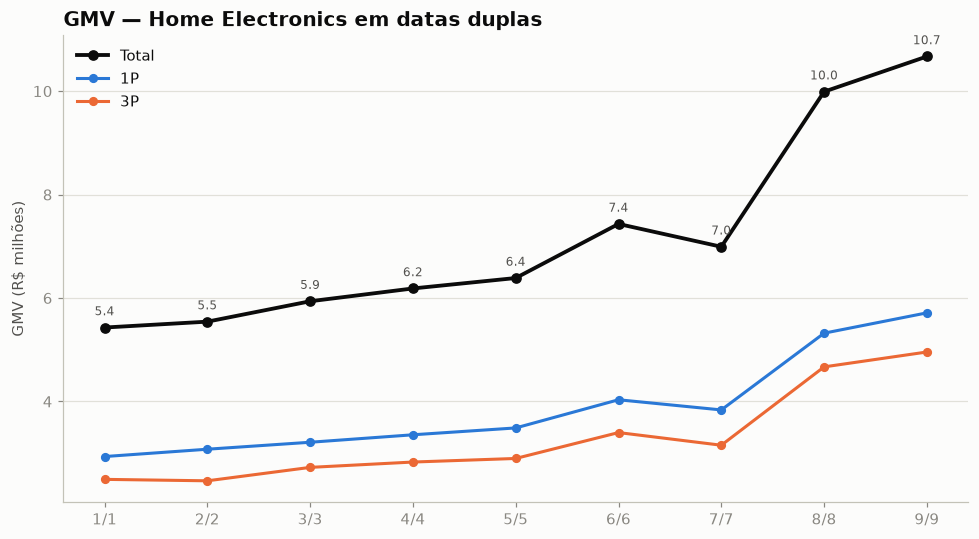

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(CHRONO_ORDER))

ax.plot(x, overall["gmv"] / 1e6, color=TEXT_PRIMARY, linewidth=2.5,
        marker="o", markersize=6, label="Total")
ax.plot(x, by_channel_gmv["1P"] / 1e6, color=COLOR_1P, linewidth=2,
        marker="o", markersize=5, label="1P")
ax.plot(x, by_channel_gmv["3P"] / 1e6, color=COLOR_3P, linewidth=2,
        marker="o", markersize=5, label="3P")

ax.set_xticks(list(x))
ax.set_xticklabels(CHRONO_ORDER)
ax.set_ylabel("GMV (R$ milhões)")
ax.set_title("GMV — Home Electronics em datas duplas", loc="left", fontweight="bold", fontsize=13)
ax.grid(axis="y", linewidth=0.8)
ax.legend(frameon=False, loc="upper left")

for xi, yi in zip(x, overall["gmv"] / 1e6):
    ax.annotate(f"{yi:,.1f}", (xi, yi), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, color=TEXT_SECONDARY)

plt.tight_layout()
plt.savefig("chart1_gmv_trend.png", dpi=150)
plt.show()


## 8. Mix de canal (1P vs 3P) por data dupla

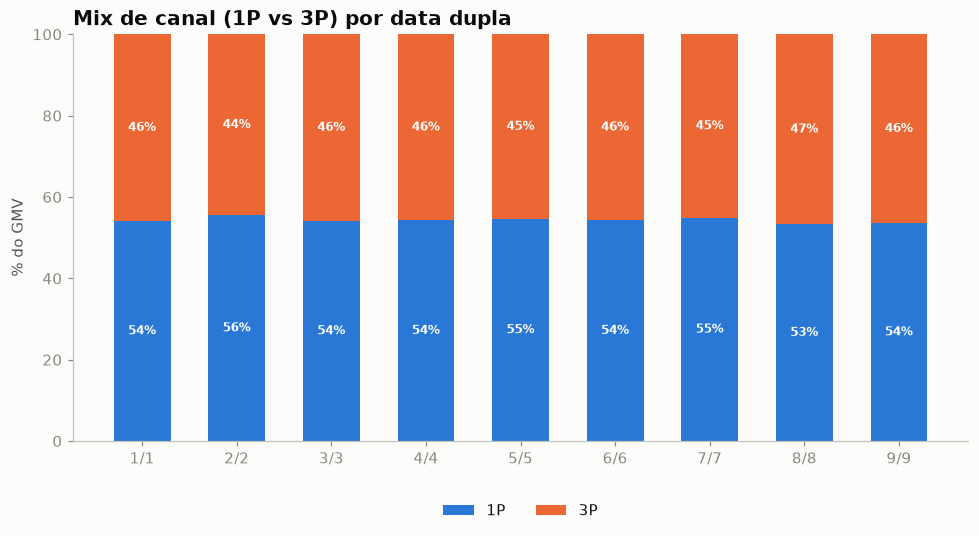

In [10]:
mix = by_channel_gmv.div(by_channel_gmv.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(CHRONO_ORDER))
for ch, color in [("1P", COLOR_1P), ("3P", COLOR_3P)]:
    vals = mix[ch].values
    ax.bar(CHRONO_ORDER, vals, bottom=bottom, color=color, label=ch, width=0.6)
    for xi, (b, v) in enumerate(zip(bottom, vals)):
        ax.annotate(f"{v:.0f}%", (xi, b + v / 2), ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    bottom += vals

ax.set_ylabel("% do GMV")
ax.set_ylim(0, 100)
ax.set_title("Mix de canal (1P vs 3P) por data dupla", loc="left", fontweight="bold", fontsize=13)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.savefig("chart2_channel_mix.png", dpi=150)
plt.show()


## 9. GMV por categoria agg1 — 9/9 vs data dupla anterior


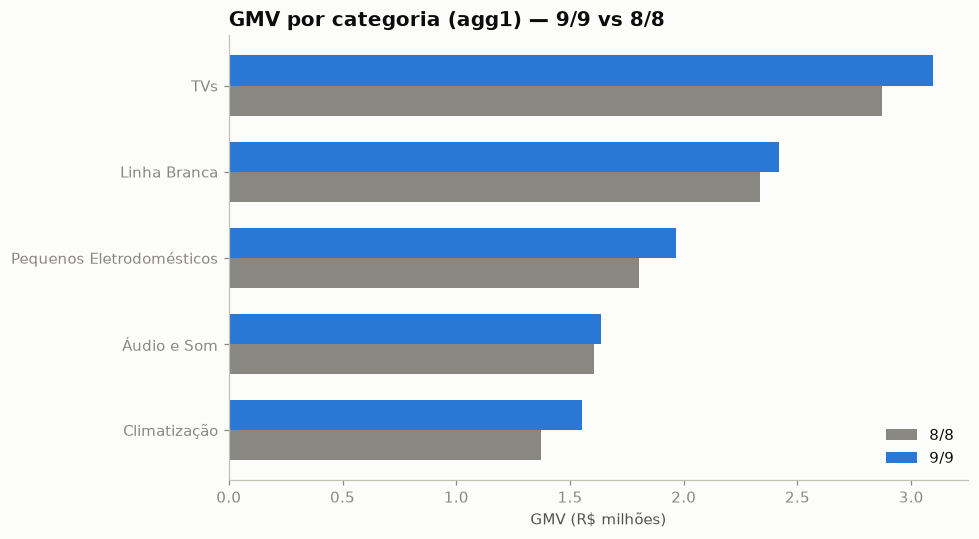

In [11]:
latest, previous = CHRONO_ORDER[-1], CHRONO_ORDER[-2]
comp = cat_gmv_pivot.loc[[previous, latest]].T / 1e6
comp = comp.sort_values(by=latest)

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(comp))
h = 0.35
ax.barh(y - h / 2, comp[previous], height=h, color=TEXT_MUTED, label=previous)
ax.barh(y + h / 2, comp[latest], height=h, color=COLOR_1P, label=latest)
ax.set_yticks(y)
ax.set_yticklabels(comp.index)
ax.set_xlabel("GMV (R$ milhões)")
ax.set_title(f"GMV por categoria (agg1) — {latest} vs {previous}", loc="left", fontweight="bold", fontsize=13)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("chart3_category_comparison.png", dpi=150)
plt.show()


## 10. Evolução do GMV por categoria agg1 em todas as datas duplas

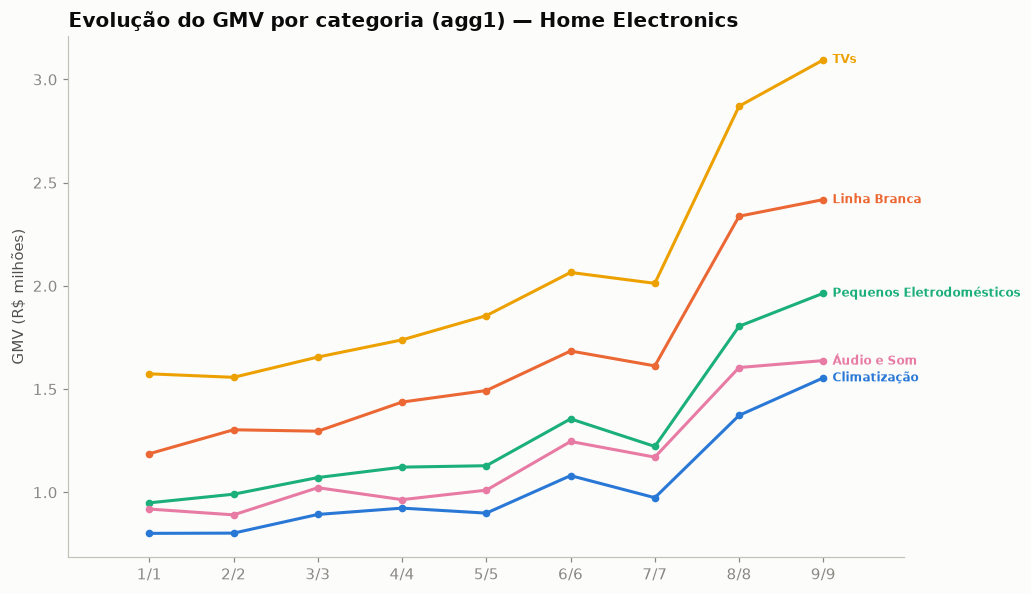

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for cat, color in zip(cat_gmv_pivot.columns, CAT_COLORS):
    series = cat_gmv_pivot[cat] / 1e6
    ax.plot(CHRONO_ORDER, series, color=color, marker="o", markersize=4, linewidth=2, label=cat)
    # rótulo direto no fim da linha (mitigação exigida p/ cores com baixo contraste)
    ax.annotate(cat, (len(CHRONO_ORDER) - 1, series.iloc[-1]), color=color,
                fontsize=8, fontweight="bold", xytext=(6, 0), textcoords="offset points",
                va="center")

ax.set_ylabel("GMV (R$ milhões)")
ax.set_title("Evolução do GMV por categoria (agg1) — Home Electronics", loc="left",
             fontweight="bold", fontsize=13)
ax.margins(x=0.12)

plt.tight_layout()
plt.savefig("chart4_category_trend.png", dpi=150)
plt.show()


## 11. Market share — Home Electronics

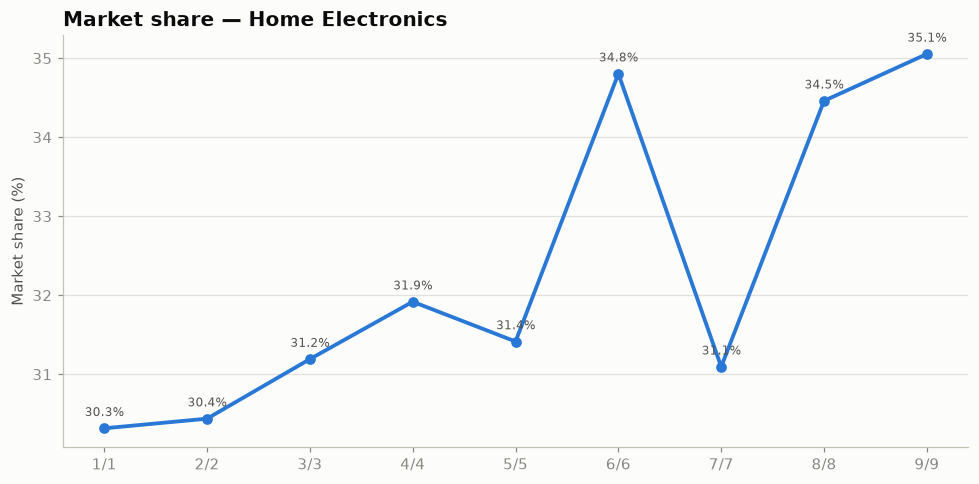

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
share_pct = overall["market_share"] * 100
ax.plot(CHRONO_ORDER, share_pct, color=COLOR_1P, marker="o", linewidth=2.5)
ax.set_ylabel("Market share (%)")
ax.set_title("Market share — Home Electronics", loc="left", fontweight="bold", fontsize=13)
ax.grid(axis="y", linewidth=0.8)

for xi, yi in enumerate(share_pct):
    ax.annotate(f"{yi:.1f}%", (xi, yi), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8, color=TEXT_SECONDARY)

plt.tight_layout()
plt.savefig("chart5_market_share.png", dpi=150)
plt.show()


## 11b. Contexto adicional de mercado (ticket médio e leitura mensal)

O share semanal (gráfico acima) é a leitura mais próxima da data dupla, mas pode ter
ruído de calendário. Aqui cruzamos com **ticket médio (ASP) de mercado** — para
diferenciar se a variação de GMV veio de volume ou preço — e, quando disponível,
a leitura **mensal** (NeoTrust/Yipit MLB) como validação de tendência.

**Extensões não exploradas neste notebook** (queries prontas na configuração, mas não
plugadas — quebram no nível de UF ou segmento, não pedido nesta análise):
`DM_MARKETSHARE_VERTICAL_D1_UF_MONTHLY`, `DM_MARKETSHARE_SEGMENTATION_NEOTRUST_D1`,
`DM_MARKET_MONTHLY_PLAYERS`.


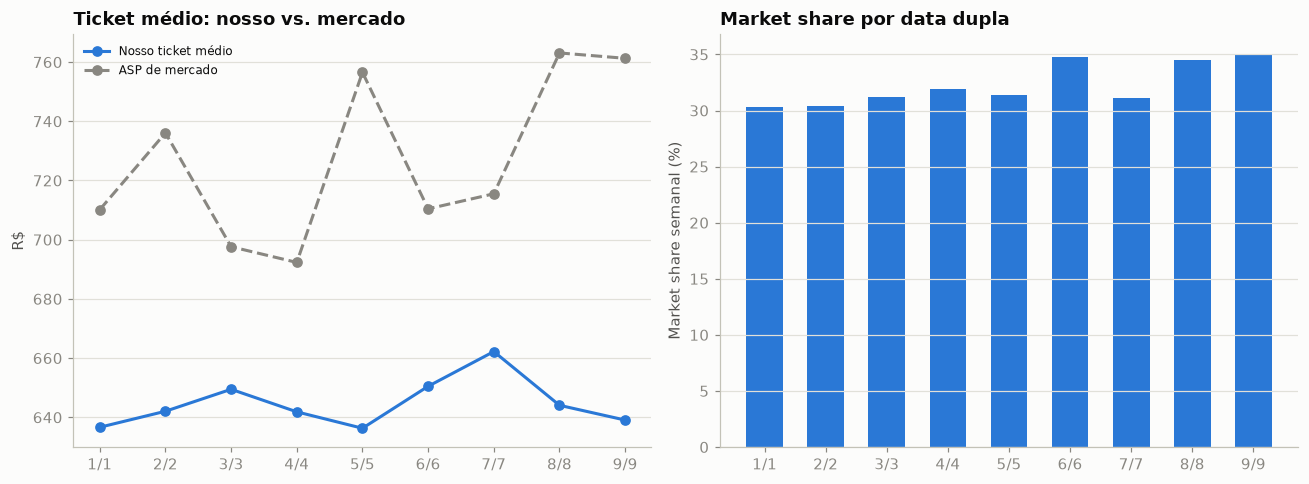

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(CHRONO_ORDER, overall["ticket_medio"], color=COLOR_1P, marker="o", linewidth=2, label="Nosso ticket médio")
ax1.plot(CHRONO_ORDER, overall["market_asp"], color=TEXT_MUTED, marker="o", linewidth=2, linestyle="--", label="ASP de mercado")
ax1.set_ylabel("R$")
ax1.set_title("Ticket médio: nosso vs. mercado", loc="left", fontweight="bold", fontsize=12)
ax1.legend(frameon=False, fontsize=8)
ax1.grid(axis="y", linewidth=0.8)

share_vs_asp = overall[["market_share", "market_asp"]].copy()
share_vs_asp["market_share"] = share_vs_asp["market_share"] * 100
ax2.bar(CHRONO_ORDER, share_vs_asp["market_share"], color=COLOR_1P, width=0.6)
ax2.set_ylabel("Market share semanal (%)")
ax2.set_title("Market share por data dupla", loc="left", fontweight="bold", fontsize=12)
ax2.grid(axis="y", linewidth=0.8)

plt.tight_layout()
plt.savefig("chart6_contexto_mercado.png", dpi=150)
plt.show()


## 12. Tabela-resumo e export

In [15]:
summary = overall.copy()
summary["gmv_growth"] = summary["gmv_growth"] * 100
summary["units_growth"] = summary["units_growth"] * 100
summary["market_share"] = summary["market_share"] * 100

summary_display = summary.rename(columns={
    "gmv": "GMV (R$)",
    "units": "Unidades",
    "ticket_medio": "Ticket médio (R$)",
    "market_asp": "ASP mercado (R$)",
    "market_share": "Market Share (%)",
    "gmv_growth": "Δ GMV vs data dupla anterior (%)",
    "units_growth": "Δ Unidades vs data dupla anterior (%)",
})[["GMV (R$)", "Unidades", "Ticket médio (R$)", "ASP mercado (R$)", "Market Share (%)",
    "Δ GMV vs data dupla anterior (%)", "Δ Unidades vs data dupla anterior (%)"]]

summary_display.to_csv("resumo_datas_duplas_home_electronics.csv")
summary_display


,GMV (R$),Unidades,Ticket médio (R$),ASP mercado (R$),Market Share (%),Δ GMV vs data dupla anterior (%),Δ Unidades vs data dupla anterior (%)
date_label,,,,,,,
1/1,"5,429,587.62","8,528.50",636.64,710.13,30.32,NaN,NaN
2/2,"5,543,388.36","8,633.90",642.05,736.08,30.44,2.10,1.24
3/3,"5,937,549.93","9,142.18",649.47,697.63,31.19,7.11,5.89
4/4,"6,185,178.04","9,636.47",641.85,692.32,31.92,4.17,5.41
5/5,"6,386,852.98","10,037.45",636.30,756.54,31.41,3.26,4.16
6/6,"7,432,176.48","11,425.63",650.48,710.42,34.80,16.37,13.83
7/7,"6,990,946.53","10,556.95",662.21,715.51,31.09,-5.94,-7.60
8/8,"9,989,330.62","15,510.02",644.06,763.09,34.46,42.89,46.92
9/9,"10,669,932.90","16,696.08",639.07,761.27,35.05,6.81,7.65


## 13. Resumo formatado (texto pronto para compartilhar)

Gera o resumo no mesmo formato usado para outras verticais (NMV, MS, ranking entre as
double dates do ano e quebra por segmento). Não inclui Target/BPC/%Afiliados/%MeliConnect/CBT
— essas métricas não têm fonte de dados definida neste notebook.


In [16]:
def fmt_brl_millions(v):
    return f"R${v / 1e6:,.2f}M".replace(",", "@").replace(".", ",").replace("@", ".")


def fmt_pct(v, signed=True):
    sign = "+" if (signed and v >= 0) else ("-" if v < 0 else "")
    return f"{sign}{abs(v):.1f}%".replace(".", ",")


def fmt_pp(v):
    sign = "+" if v >= 0 else "-"
    return f"{sign}{abs(v):.2f}pp".replace(".", ",")


def build_formatted_summary(target_label, vertical_name=AGG1_VERTICAL):
    idx = CHRONO_ORDER.index(target_label)
    prev_label = CHRONO_ORDER[idx - 1] if idx > 0 else None
    year = DOUBLE_DATES[0][1].year

    row = overall.loc[target_label]
    nmv = row["gmv"]
    ms = row["market_share"] * 100

    lines = [f"Resultados {vertical_name}:"]

    nmv_extra = []
    if prev_label:
        nmv_extra.append(f"({fmt_pct(row['gmv_growth'] * 100)} vs {prev_label})")
    if pd.notna(row.get("yoy_growth")):
        nmv_extra.append(f"{fmt_pct(row['yoy_growth'] * 100)} YoY")
    if pd.notna(row.get("mom_growth")):
        nmv_extra.append(f"{fmt_pct(row['mom_growth'] * 100)} MoM")
    lines.append(f"NMV {fmt_brl_millions(nmv)} " + " | ".join(nmv_extra))

    ms_line = f"MS {fmt_pct(ms, signed=False)}"
    if prev_label:
        ms_delta = ms - overall.loc[prev_label, "market_share"] * 100
        ms_line += f" ({fmt_pp(ms_delta)} vs {prev_label})"
    lines.append(ms_line)
    lines.append("")

    # Ranking entre todas as double dates do ano (mais recente primeiro)
    others = [l for l in reversed(CHRONO_ORDER) if l != target_label]
    diffs_text = ", ".join(f"{fmt_pct((nmv / overall.loc[l, 'gmv'] - 1) * 100)} vs {l}" for l in others)
    rank = int((overall["gmv"] > nmv).sum()) + 1
    n_dates = len(CHRONO_ORDER)
    record_tag = " (récord del año)" if rank == 1 else ""
    lines.append(f"Ranking NMV {vertical_name} — double dates de {year}:")
    lines.append(f"{rank}º lugar{record_tag} entre las {n_dates} double dates de {year}: {diffs_text}.")
    lines.append("")

    # Por segmento (1P / 3P)
    lines.append(f"{vertical_name} por segmento:")
    for ch in ["1P", "3P"]:
        ch_nmv = by_channel_gmv.loc[target_label, ch]
        line = f"{ch}: NMV {fmt_brl_millions(ch_nmv)}"
        if prev_label:
            ch_prev = by_channel_gmv.loc[prev_label, ch]
            ch_growth = (ch_nmv / ch_prev - 1) * 100
            line += f" ({fmt_pct(ch_growth)} vs {prev_label})"
        lines.append(line)

    return "\n".join(lines)


print(build_formatted_summary(CHRONO_ORDER[-1]))


Resultados Home Electronics:
NMV R$10,67M (+6,8% vs 8/8) | +60,0% YoY | +18,6% MoM
MS 35,1% (+0,59pp vs 8/8)

Ranking NMV Home Electronics — double dates de 2026:
1º lugar (récord del año) entre las 9 double dates de 2026: +6,8% vs 8/8, +52,6% vs 7/7, +43,6% vs 6/6, +67,1% vs 5/5, +72,5% vs 4/4, +79,7% vs 3/3, +92,5% vs 2/2, +96,5% vs 1/1.

Home Electronics por segmento:
1P: NMV R$5,71M (+7,4% vs 8/8)
3P: NMV R$4,96M (+6,2% vs 8/8)


## 14. Conclusões (preencher após rodar com dados reais)

- **GMV 9/9 vs 8/8:** _(ex.: cresceu X% impulsionado por categoria Y e canal Z)_
- **Canal:** _(1P ou 3P ganhou/perdeu participação? em quais categorias?)_
- **Categoria:** _(qual subcategoria de Home Electronics liderou o crescimento/queda?)_
- **Market share:** _(ganhamos ou perdemos share vs o mercado nesta data dupla, segundo NeoTrust/Yipit?)_
- **Preço vs volume:** _(o GMV variou mais por ticket médio ou por unidades, comparado ao ASP de mercado?)_
- **Próximos passos:** _(ex.: investigar ruptura de estoque, efeito de campanha, comparar YoY, plugar as
  extensões de UF/segmento/ranking de players se necessário)_
